# HNW & SWE Validation — dSnow (SnowToSwe, Python port)

Validates the **Winkler et al. 2021 Δ-Snow** model against the **Mag25** dataset.

**Model**: `SnowToSwe` (pure-Python port of the R `nixmass::swe.delta.snow` by M. Theurl),
run with the original Winkler 2021 default parameters.

**Workflow**
1. Load the multi-station NetCDF (`Mag25_all.nc`).
2. Run `SnowToSwe.convert_list(...)` on each station's HS series → `SWE_mod`.
3. Derive `HNW_mod` from day-to-day `SWE_mod` increments (negative melt diffs clipped to 0).
4. Validate **HNW** and **SWE** against observations, restricted to days with a valid `SWE_obs`
   (biweekly snow-course surveys — avoids inflating stats with unobserved days).
5. Cross-check the Python run against the R `nixmass` implementation on a single
   station/season (Adelboden 2016/17); CSV must first be generated by
   `adelboden_nixmass_single_season.R`.


In [32]:
import sys
import os
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# ── Project root ─────────────────────────────────────────────────────────────
base_dir = Path("/Users/jakobwerkgarner/code/mt_dsnow")
os.chdir(base_dir)

# ── Paths ─────────────────────────────────────────────────────────────────────
Mag25_nc_file = "/Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc"
save_dir      = base_dir / "HNW_validation/validation_plots"

# ── Local imports ─────────────────────────────────────────────────────────────
import HNW_validation.HNW_validation_helper as val_helper

sys.path.insert(0, str(base_dir / "snow_to_swe_master"))
from main import SnowToSwe

warnings.filterwarnings("ignore", category=FutureWarning, module=r"main")

# ── Run configuration ─────────────────────────────────────────────────────────
model_source  = "SnowToSwe"
calib_comment = "None"
save_data     = False




In [33]:
# snow_to_swe = SnowToSwe(
#     rho_max=449.63,
#     rho_null=87.16,
#     c_ov=0.0063333,
#     k_ov=0.303018,
#     k=0.0829424,
#     tau=0.00972295,
#     eta_null=6.18233e7,
# )  # 38, 1, 4#38, 1,4


# snow_to_swe = SnowToSwe(
#     rho_max=381.203,
#     rho_null=106.832,
#     c_ov=0.00055347,
#     k_ov=0.403141,
#     k=0.0272148,
#     tau=0.0222341,
#     eta_null=8.65803e+06,
# )#. 37.6, 2.9

# snow_to_swe = SnowToSwe() #'32.8' , -17.9


snow_to_swe = SnowToSwe(
    rho_max=429.68,
    rho_null=108.35,
    c_ov=0.000547096,
    k_ov=0.398759,
    k=0.0259823,
    tau=0.0217061,
    eta_null=8457610.0,
)


print(f"model_source  : {model_source}")
print(f"Mag25_nc_file : {Mag25_nc_file}")
print(f"calib_comment : {calib_comment}")

This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'
model_source  : SnowToSwe
Mag25_nc_file : /Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc
calib_comment : None


In [34]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm

# ── Load Mag25 multi-station NetCDF (FULL YEAR — do NOT pre-filter) ──────────
# Running SnowToSwe per-winter requires each call to end on a snow-free day.
# If we cut at Apr 30, stations with snow still on the ground that day crash
# SnowToSwe's internal loop. Using hydrological years Sep 1 -> Aug 31 lets
# the summer naturally bring HS to 0 at the boundaries.

Mag25_data = xr.open_dataset(Mag25_nc_file)
Mag25_data = Mag25_data.drop_sel(station="Weisfluh_Joch")

Mag25_data_with_SWE = Mag25_data.copy()
Mag25_data_with_SWE["SWE_mod"] = xr.full_like(Mag25_data_with_SWE["HS"], np.nan)

times        = pd.to_datetime(Mag25_data["time"].values)
hyd_year     = np.where(times.month > 8, times.year, times.year - 1)   # ← fix typo
winter_years = np.unique(hyd_year)



# ── Per-(station × hydrological year) worker ─────────────────────────────────
def process_station_winter(station_name, winter_year,
                           time_idx, hs_values, snow_to_swe):
    """Run SnowToSwe on ONE station × ONE hydrological year (Sep–Aug)."""
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=DeprecationWarning)

    try:
        hs = pd.Series(hs_values).fillna(0).clip(lower=0).astype(float)
        if len(hs) == 0:
            return None
        # SnowToSwe preconditions: series must start at 0
        if hs.iloc[0] != 0:
            hs.iloc[0] = 0.0
        if hs.iloc[-1] != 0:
            hs.iloc[-1] = 0.0        # ← add this

        swe_list = snow_to_swe.convert_list(hs.tolist(),
                                            timestep=24, verbose=False)
        if swe_list is None:
            return None

        swe_arr = np.asarray(swe_list, dtype=float)
        assert swe_arr.shape[0] == len(hs)
        return (station_name, winter_year, time_idx, swe_arr)
    except Exception as e:
        return ("__ERROR__", station_name,
                f"winter {winter_year}/{winter_year + 1}: {e}")


# ── Build (station × winter) task list ───────────────────────────────────────
station_list = Mag25_data["station"].values
hs_by_stn    = {s: Mag25_data["HS"].sel(station=s).values for s in station_list}

tasks = []
for stn in station_list:
    hs_full = hs_by_stn[stn]
    for y in winter_years:
        mask     = hyd_year == y
        time_idx = times[mask].values
        hs_vals  = hs_full[mask]
        tasks.append((stn, int(y), time_idx, hs_vals))

n_jobs = -1
print(f"Running SnowToSwe on {len(station_list)} stations × "
      f"{len(winter_years)} hydrological years = {len(tasks)} tasks "
      f"(parallel, n_jobs={n_jobs})…")

results = []
with tqdm(total=len(tasks), desc="Station×Winter", unit="task") as pbar:
    for r in Parallel(n_jobs=n_jobs, return_as="generator")(
        delayed(process_station_winter)(stn, y, tidx, hsv, snow_to_swe)
        for (stn, y, tidx, hsv) in tasks
    ):
        results.append(r)
        pbar.update(1)


# ── Collect results back into SWE_mod ────────────────────────────────────────
errors      = []
ok_tasks    = 0
ok_stations = set()

for result in results:
    if result is None:
        continue
    if isinstance(result, tuple) and result and result[0] == "__ERROR__":
        errors.append((result[1], result[2]))
        continue

    station_name, wyr, time_idx, swe_arr = result
    Mag25_data_with_SWE["SWE_mod"].loc[
        dict(station=station_name, time=time_idx)
    ] = swe_arr
    ok_tasks += 1
    ok_stations.add(station_name)


# ── Observation counts per station ───────────────────────────────────────────
obs_counts_df = pd.DataFrame([
    {"station": s,
     "n_obs": int(Mag25_data["SWE"].sel(station=s).notnull().sum().item())}
    for s in station_list
])

print(f"\nDone. Tasks processed: {ok_tasks} / {len(tasks)}")
print(f"Stations with ≥1 successful winter: "
      f"{len(ok_stations)} / {len(station_list)}")
print(f"Hydrological years: {list(winter_years)} ({len(winter_years)} seasons)")
print(f"Total time steps (full year): {Mag25_data.sizes['time']}")

if errors:
    print(f"\nErrors on {len(errors)} (station, winter) pair(s):")
    for stn, msg in errors:
        print(f"  {stn}: {msg}")

Running SnowToSwe on 40 stations × 6 hydrological years = 240 tasks (parallel, n_jobs=-1)…


Station×Winter: 100%|██████████| 240/240 [00:47<00:00,  5.00task/s]


Done. Tasks processed: 240 / 240
Stations with ≥1 successful winter: 40 / 40
Hydrological years: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)] (6 seasons)
Total time steps (full year): 2191


## Validation

Density scatter of observed vs. modelled SWE, using the same filtered subset
as the HNW validation above (identical N).


Rows total      :   87640
Rows w/ SWE_obs :    1054
Rows w/ HNW_obs :   35409
HNW stats: {'RMSE': np.float64(3.0645301661302873), 'Bias': np.float64(0.14436965457851603), 'Rel_BIAS': np.float64(0.07053932798358871), 'R2': np.float64(0.8166101006989791), 'N': 35409}
SWE stats: {'RMSE': np.float64(50.68997870183688), 'Bias': np.float64(32.041352355923685), 'Rel_BIAS': np.float64(0.16122381791368684), 'R2': np.float64(0.8269532540397594), 'N': 1054}


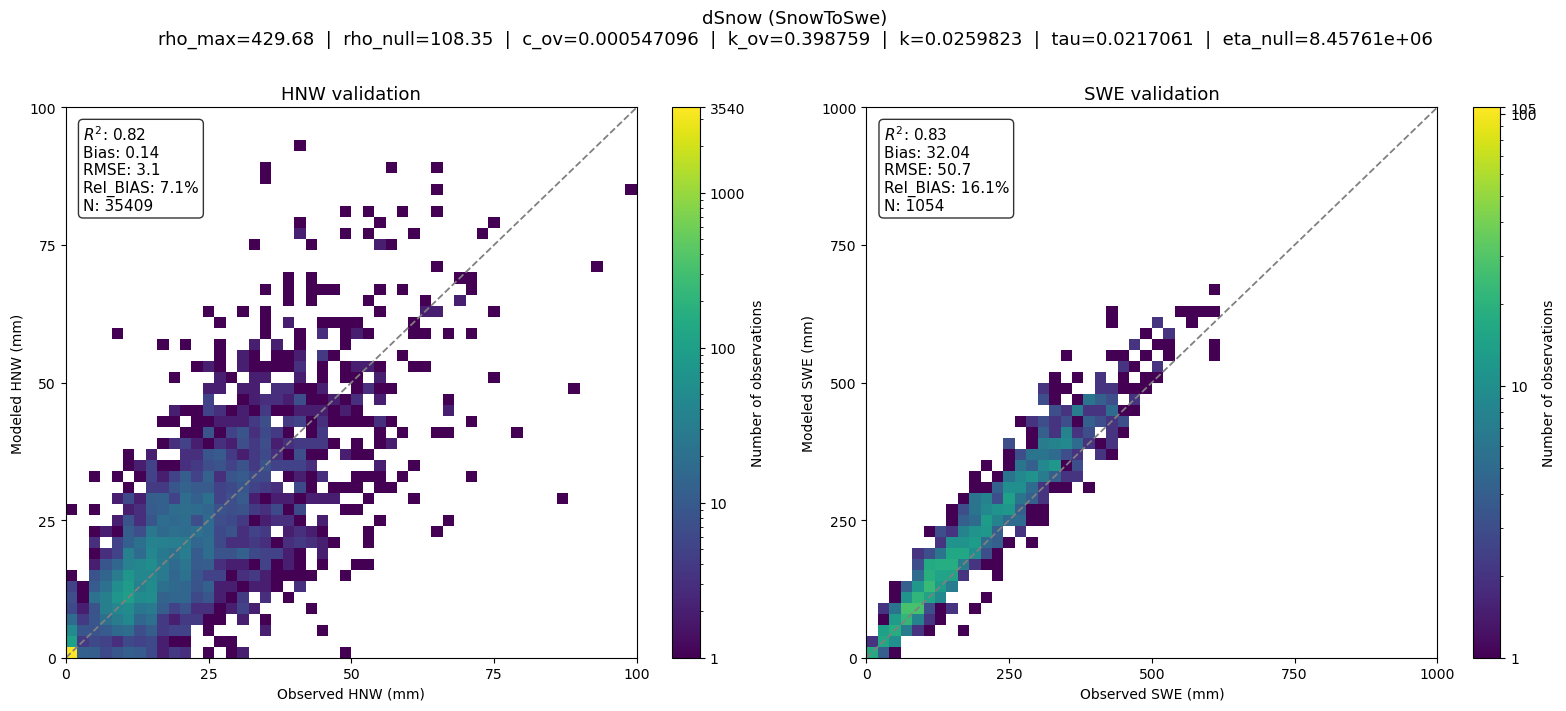

{'HNW': {'RMSE': np.float64(3.0645301661302873), 'Bias': np.float64(0.14436965457851603), 'Rel_BIAS': np.float64(0.07053932798358871), 'R2': np.float64(0.8166101006989791), 'N': 35409}, 'SWE': {'RMSE': np.float64(50.68997870183688), 'Bias': np.float64(32.041352355923685), 'Rel_BIAS': np.float64(0.16122381791368684), 'R2': np.float64(0.8269532540397594), 'N': 1054}}


In [35]:

# ── Derive HNW_mod from day-to-day SWE_mod increments ────────────────────────
# Negative diffs represent melt, not new snow, so clip them to 0.
# .reindex() restores the full time axis (diff drops the first timestep).

HNW_mod = Mag25_data_with_SWE["SWE_mod"].diff(dim="time").clip(min=0)
HNW_mod = HNW_mod.reindex(time=Mag25_data_with_SWE["time"])

Mag25_data_with_SWE["HNW_mod"] = HNW_mod

# ── Build one long-format frame with both pairs (obs & mod) ─────────────────
all_df = (Mag25_data_with_SWE[["HNW", "HNW_mod", "SWE", "SWE_mod", "HS"]]
          .to_dataframe()
          .reset_index()
          .rename(columns={"HNW": "HNW_obs", "SWE": "SWE_obs"}))

# ── Keep only days with a valid observed SWE ────────────────────────────────
# Mag25 SWE is biweekly snow-course data (NaN on most days). Validating on the
# observed days only yields statistically meaningful RMSE / R², and puts the
# HNW and SWE comparisons onto the same subset of rows.

SWE_val = all_df[all_df["SWE_obs"].notna()].copy()


HNW_val = all_df[all_df["HNW_obs"].notna()].copy()
HNW_val.index = pd.to_datetime(HNW_val["time"]).values



print(f"Rows total      : {len(all_df):>7}")
print(f"Rows w/ SWE_obs : {len(SWE_val):>7}")
print(f"Rows w/ HNW_obs : {len(HNW_val):>7}")



# val_helper.validate_swe_mag25(
#     SWE_val,
#     full_season= True,
#     model_name = "dSnow (SnowToSwe)",
#     obs_col    = "SWE_obs",
#     mod_col    = "SWE_mod",
#     save_dir   = save_dir,
#     filename   = f"SnowToSwe_SWE_validation_{calib_comment}.png",
# )

# val_helper.validate_hnw_mag25(
#     HNW_val,
#     full_season = False,
#     model_name = "dSnow (SnowToSwe)",
#     obs_col    = "HNW_obs",
#     mod_col    = "HNW_mod",
#     save_dir   = save_dir,
#     filename   = f"SnowToSwe_hnw_validation_{calib_comment}.png",
# )


# ── Extract parameters from the SnowToSwe instance ──────────────────────────
params = dict(
    rho_max   = snow_to_swe.rho_max,
    rho_null  = snow_to_swe.rho_null,
    c_ov      = snow_to_swe.c_ov,
    k_ov      = snow_to_swe.k_ov,
    k         = snow_to_swe.k,
    tau       = snow_to_swe.tau,
    eta_null  = snow_to_swe.eta_null,
)

results = val_helper.validate_hnw_swe_combined(
    hnw_df     = HNW_val,
    swe_df     = SWE_val,
    model_name = "dSnow (SnowToSwe)",
    params     = params,
    full_season= False,
    #save_dir   = save_dir,
    #filename   = f"SnowToSwe_combined_validation_{calib_comment}.png",
)

print(results)

In [12]:
import pandas as pd

df = pd.read_csv("/Users/jakobwerkgarner/code/mt_dsnow/calibration/opt_results_all.csv")

KEY_MAP = {
    "rho.max": "rho_max", "rho.null": "rho_null",
    "c.ov":    "c_ov",    "k.ov":     "k_ov",
    "k":       "k",       "tau":      "tau",
    "eta.null": "eta_null",
}

def parse_best_par(s):
    out = {}
    for part in str(s).split(";"):
        part = part.strip()
        if not part:
            continue
        k, v = part.split("=", 1)
        out[KEY_MAP.get(k.strip(), k.strip().replace(".", "_"))] = float(v)
    return out

# Sort ascending: lowest best_value first (= best fit)
df_sorted = df.sort_values("best_value", ascending=True).reset_index(names="orig_idx")

for rank, row in df_sorted.iterrows():
    best_par = parse_best_par(row["best_par"])

    print(f"# rank={rank}  orig_idx={row['orig_idx']}  "
          f"{row['dataset']}  {row['algorithm']}  "
          f"w=({row['w_SWE_NRMSE']},{row['w_RHO_NRMSE']},{row['w_SWE_NBIAS']})  "
          f"best_value={row['best_value']:.6f}")
    print("snow_to_swe = SnowToSwe(")
    for k, v in best_par.items():
        print(f"    {k}={v!r},")
    print(")")
    print()  # blank line between blocks

# rank=0  orig_idx=5  nan  DE  w=(0.7,0.0,0.3)  best_value=0.086399
snow_to_swe = SnowToSwe(
    rho_max=458.442,
    rho_null=77.977,
    c_ov=0.0077715,
    k_ov=0.256329,
    k=0.0183345,
    tau=0.00556525,
    eta_null=73629900.0,
)

# rank=1  orig_idx=4  nan  DE  w=(0.6,0.2,0.2)  best_value=0.099455
snow_to_swe = SnowToSwe(
    rho_max=452.348,
    rho_null=82.5591,
    c_ov=0.00781369,
    k_ov=0.370169,
    k=0.0684356,
    tau=0.00455964,
    eta_null=89837700.0,
)

# rank=2  orig_idx=1  nan  DE  w=(0.3,0.5,0.2)  best_value=0.099607
snow_to_swe = SnowToSwe(
    rho_max=448.561,
    rho_null=82.4022,
    c_ov=0.00750225,
    k_ov=0.290586,
    k=0.0779814,
    tau=0.00375516,
    eta_null=64141000.0,
)

# rank=3  orig_idx=8  nan  DE  w=(1.0,0.0,0.0)  best_value=0.110759
snow_to_swe = SnowToSwe(
    rho_max=466.089,
    rho_null=74.8493,
    c_ov=0.00914176,
    k_ov=0.4154,
    k=0.00957791,
    tau=0.0267723,
    eta_null=76290600.0,
)

# rank=4  orig_idx=7  nan  DE  w=(0.8,0.

# DO it all

In [13]:
# ============================================================
# Validate ALL parameter sets on Mag25 → one grid figure per variable
# ============================================================
from joblib import Parallel, delayed
from tqdm.auto import tqdm

# ── Param sets: load, parse, sort by best_value ──────────────────────────────
df = pd.read_csv("/Users/jakobwerkgarner/code/mt_dsnow/calibration/opt_results_all.csv")

KEY_MAP = {
    "rho.max":  "rho_max", "rho.null": "rho_null",
    "c.ov":     "c_ov",    "k.ov":     "k_ov",
    "k":        "k",       "tau":      "tau",
    "eta.null": "eta_null",
}

def parse_best_par(s):
    out = {}
    for part in str(s).split(";"):
        part = part.strip()
        if not part:
            continue
        k, v = part.split("=", 1)
        out[KEY_MAP.get(k.strip(), k.strip().replace(".", "_"))] = float(v)
    return out

df_sorted = df.sort_values("best_value", ascending=True).reset_index(names="orig_idx")

TOP_N = None        # None = all rows; otherwise e.g. 12 for the 12 best
if TOP_N is not None:
    df_sorted = df_sorted.head(TOP_N).reset_index(drop=True)

print(f"Validating {len(df_sorted)} parameter sets")

# ── Build (station × winter) task list ONCE (HS data doesn't change) ─────────
station_list = Mag25_data["station"].values
hs_by_stn    = {s: Mag25_data["HS"].sel(station=s).values for s in station_list}

tasks_meta = []
for stn in station_list:
    hs_full = hs_by_stn[stn]
    for y in winter_years:
        mask = hyd_year == y
        tasks_meta.append((stn, int(y), times[mask].values, hs_full[mask]))

print(f"Tasks per parameter set: {len(tasks_meta)} "
      f"({len(station_list)} stations × {len(winter_years)} winters)")

# ── Per-(station × winter) worker (same as before) ───────────────────────────
def process_station_winter(station_name, winter_year, time_idx, hs_values,
                           snow_to_swe):
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    try:
        hs = pd.Series(hs_values).fillna(0).clip(lower=0).astype(float)
        if len(hs) == 0:
            return None
        if hs.iloc[0]  != 0: hs.iloc[0]  = 0.0
        if hs.iloc[-1] != 0: hs.iloc[-1] = 0.0
        swe_list = snow_to_swe.convert_list(hs.tolist(),
                                            timestep=24, verbose=False)
        if swe_list is None:
            return None
        return (station_name, winter_year, time_idx,
                np.asarray(swe_list, dtype=float))
    except Exception as e:
        return ("__ERROR__", station_name,
                f"winter {winter_year}: {e}")

# ── Run one parameter set → return (SWE_val, HNW_val) DataFrames ─────────────
def run_one_paramset(best_par):
    snow    = SnowToSwe(**best_par)
    swe_mod = xr.full_like(Mag25_data["HS"], np.nan)

    results = Parallel(n_jobs=-1)(
        delayed(process_station_winter)(stn, y, tidx, hsv, snow)
        for (stn, y, tidx, hsv) in tasks_meta
    )

    for r in results:
        if r is None or (isinstance(r, tuple) and r[0] == "__ERROR__"):
            continue
        stn, _y, tidx, arr = r
        swe_mod.loc[dict(station=stn, time=tidx)] = arr

    ds = Mag25_data.copy()
    ds["SWE_mod"] = swe_mod
    ds["HNW_mod"] = (swe_mod.diff(dim="time").clip(min=0)
                            .reindex(time=ds["time"]))

    long_df = (ds[["HNW", "HNW_mod", "SWE", "SWE_mod", "HS"]]
               .to_dataframe().reset_index()
               .rename(columns={"HNW": "HNW_obs", "SWE": "SWE_obs"}))

    swe_val = long_df[long_df["SWE_obs"].notna()].copy()
    hnw_val = long_df[long_df["HNW_obs"].notna()].copy()
    return swe_val, hnw_val

# ── Stats helper ─────────────────────────────────────────────────────────────
def metrics(obs, mod):
    obs = np.asarray(obs, float); mod = np.asarray(mod, float)
    m   = np.isfinite(obs) & np.isfinite(mod)
    obs, mod = obs[m], mod[m]
    if len(obs) < 2:
        return dict(N=len(obs), rmse=np.nan, bias=np.nan, r2=np.nan)
    return dict(
        N    = len(obs),
        rmse = float(np.sqrt(np.mean((mod - obs) ** 2))),
        bias = float(np.mean(mod - obs)),
        r2   = float(np.corrcoef(obs, mod)[0, 1] ** 2),
    )

# ── Loop over all parameter sets ─────────────────────────────────────────────
swe_results, hnw_results, headers, params_list = [], [], [], []

for rank, row in tqdm(df_sorted.iterrows(), total=len(df_sorted),
                      desc="Parameter sets"):
    bp = parse_best_par(row["best_par"])
    swe_v, hnw_v = run_one_paramset(bp)

    swe_results.append(swe_v)
    hnw_results.append(hnw_v)
    params_list.append(bp)
    headers.append(
        f"#{rank} [{row['orig_idx']}]  "
        f"{row['dataset']}/{row['algorithm']}  "
        f"w=({row['w_SWE_NRMSE']},{row['w_RHO_NRMSE']},{row['w_SWE_NBIAS']})  "
        f"bv={row['best_value']:.4f}"
    )

# ── Grid plotter ─────────────────────────────────────────────────────────────
def plot_grid(data_list, headers, params_list, obs_col, mod_col,
              var_label, units, fname, ncols=6):
    n     = len(data_list)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3.6 * ncols, 3.9 * nrows),
                             squeeze=False, sharex=True, sharey=True)

    # global axis limit so subplots are comparable
    vmax = 0.0
    for d in data_list:
        if len(d):
            vmax = max(vmax, float(d[[obs_col, mod_col]].max().max()))
    vmax *= 1.05

    for i, (d, hdr, bp) in enumerate(zip(data_list, headers, params_list)):
        ax = axes[i // ncols][i % ncols]
        x  = d[obs_col].values
        y  = d[mod_col].values
        m  = np.isfinite(x) & np.isfinite(y)

        if m.sum() >= 2:
            ax.hexbin(x[m], y[m], gridsize=40, mincnt=1,
                      extent=(0, vmax, 0, vmax), cmap="viridis")
        ax.plot([0, vmax], [0, vmax], "k--", lw=0.8, alpha=0.6)

        s = metrics(x, y)
        ax.text(0.04, 0.96,
                f"N={s['N']}\nRMSE={s['rmse']:.1f}\n"
                f"Bias={s['bias']:+.1f}\nR²={s['r2']:.3f}",
                transform=ax.transAxes, va="top", ha="left",
                fontsize=7,
                bbox=dict(boxstyle="round,pad=0.25",
                          fc="white", ec="0.7", alpha=0.85))

        # title: rank/dataset/weights line + two compact param lines
        p1 = (f"rho_max={bp['rho_max']:.1f}  rho_null={bp['rho_null']:.1f}  "
              f"c_ov={bp['c_ov']:.3g}  k_ov={bp['k_ov']:.3g}")
        p2 = (f"k={bp['k']:.4g}  tau={bp['tau']:.4g}  "
              f"eta_null={bp['eta_null']:.3g}")
        ax.set_title(hdr + "\n" + p1 + "\n" + p2,
                     fontsize=6.5, loc="left")

        ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
        ax.set_aspect("equal", adjustable="box")

    # hide unused cells
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)

    fig.supxlabel(f"Observed {var_label} [{units}]")
    fig.supylabel(f"Modelled {var_label} [{units}]")
    fig.suptitle(
        f"{var_label} validation across {n} parameter sets — Mag25, SnowToSwe",
        fontsize=12, y=0.995,
    )
    fig.tight_layout()
    out_path = save_dir / fname
    fig.savefig(out_path, dpi=140, bbox_inches="tight")
    print("saved →", out_path)
    return fig

save_dir.mkdir(parents=True, exist_ok=True)

plot_grid(swe_results, headers, params_list,
          obs_col="SWE_obs", mod_col="SWE_mod",
          var_label="SWE", units="mm",
          fname="SnowToSwe_SWE_validation_GRID.png")

plot_grid(hnw_results, headers, params_list,
          obs_col="HNW_obs", mod_col="HNW_mod",
          var_label="HNW", units="mm",
          fname="SnowToSwe_HNW_validation_GRID.png")

plt.show()

Validating 19 parameter sets
Tasks per parameter set: 240 (40 stations × 6 winters)


Parameter sets:   0%|          | 0/19 [00:00<?, ?it/s]

This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakob

This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakob

This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakob

KeyboardInterrupt: 